# Prorating Face Values Step 2

A daily prorated value was determined in Step 1. The length of the superseason was also calculated in Step 1. Now, determine the number of superseason days in each calendar month. Then multiply the number of days in each month by the daily prorated value. The result is a monthly prorated value. This can be compared with the reported monthly averages for each water right.

In [ ]:
import pandas as pd
import numpy as np
import datetime
import ast
import seaborn as sns
import matplotlib.pyplot as plt
from shiny import App, render, ui, reactive

NV_table = pd.read_csv("../Outputs/NV_proratedFaceValues_python.csv") # Pandas reads the list columns (DIV_DAYS_LIST, STO_DAYS_LIST, etc.) as text strings rather than lists. Convert from strings back to lists as below

# x represents the value in a cell within the specified column.
# Use apply() on a column, and pandas goes through the column one row at a time.
# These apply the lambda function to x by using the ast module's literal_eval function on x. If x is not na and is a string, the ast module converts it to a list. If x is NaN, pd.notna(x) would be False, and the output in that cell would be NaN.
NV_table['DIV_DAYS_LIST'] = NV_table['DIV_DAYS_LIST'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) and isinstance(x, str) else x
)

NV_table['STO_DAYS_LIST'] = NV_table['STO_DAYS_LIST'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) and isinstance(x, str) else x
)

### Calculate the number of superseason days in each calendar month

R operation being rewritten

```
unique_days_month <- function(div_list, sto_list, year = 2024) {
  
  all_days <- unique(c(div_list, sto_list)) # takes div_list, sto_list and combines them; then removes duplicates, assigns result to all_days
  all_days <- all_days[!is.na(all_days)] # all_days is evaluated to return those that are not NA
  
  # past year parameter in front of "01-01" and call that the origin. 
  # get the date of all_days that have been formatted as YYYY-MM-DD
  dates <- as.Date(all_days, origin = paste0(year, "-01-01"))
  
  # create table called counts that will count the unique days in each water right's superseason
  counts <- table(month(dates))
  
  # create full_counts where 1:12 are counted then turned into numbers and each number corresponds to a month
  full_counts <- setNames(
    as.numeric(counts[as.character(1:12)] %||% 0), # return 1:12 or else return 0 (if left is not NULL return left)
    c("JAN_COUNT", "FEB_COUNT", "MAR_COUNT", "APR_COUNT", "MAY_COUNT", "JUN_COUNT",
      "JUL_COUNT", "AUG_COUNT", "SEP_COUNT", "OCT_COUNT", "NOV_COUNT", "DEC_COUNT") # 1 corresponds to JAN_COUNT, etc.
  )
  
  full_counts
}

# create new tibble with results of function
# add columns to new tibble with each right's days in superseason month
NV_df <- NV_table_filter_DivSto |> # add column called month_counts
  mutate(month_counts = map2(DIV_DAYS_LIST, STO_DAYS_LIST, unique_days_month)) |> #map2(vector1, vector2, function)
  # map2 iterates over the length of the vectors while executing the function (taking i-th element of each vector)
  unnest_wider(month_counts) # month_counts is a list of length 238; each row in NV_df has column month_counts
  # in month_counts is JAN_COUNT, FEB_COUNT, etc. w/ number of superseason days in each month
  # unnest_wider takes the list in each row, makes a column for each (e.g., JAN_COUNT, FEB_COUNT... column) and stores the number of days 

# Add columns to tibble for monthly prorated face value ----
NV_df <- NV_df |> add_column(
  JAN_PRO_FV = 0, FEB_PRO_FV = 0, MAR_PRO_FV = 0, APR_PRO_FV = 0,
  MAY_PRO_FV = 0, JUN_PRO_FV = 0, JUL_PRO_FV = 0, AUG_PRO_FV = 0,
  SEP_PRO_FV = 0, OCT_PRO_FV = 0, NOV_PRO_FV = 0, DEC_PRO_FV = 0
)
```

In [ ]:
# Recreate the output of the unique_days_month function

def unique_days_month(div_list, sto_list, year = 2024):
    # handle any empty/NaN lists which might result due to reading from CSV
    def clean_input(lst):
        if isinstance(lst, (list, np.ndarray, pd.Series)): # check: is lst a container of multiple values (any of: list, numpy array, or pandas series)
            return [x for x in lst if pd.notna(x)] # look at every individual item (x) in the container, remove anything that is NaN, then create new list containing only valid numbers
        elif pd.notna(lst): # if input is not container (e.g., a single number), this condition makes sure it is not NaN then puts it in a list
            return[lst]
        return [] # if input is truly empty or NaN, it returns an empty list to prevent a crash
    div_clean = clean_input(div_list)
    sto_clean = clean_input(sto_list)

    # combine and get the unique count of days
    unique_days = list(set(div_clean + sto_clean)) # creates a set by concatenating div_clean + sto_clean for each row (sets contain only unique values). Then is converted to a list structure.

    # make a dictionary (key-value pairs of the month with 0) that will be updated based on the remainder of the function when the function is called
    months_abbrev = ["JAN", "FEB", "MAR", "APR", "MAY", "JUN", "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"]
    counts = {f"{m}_COUNT": 0 for m in months_abbrev}

    if not unique_days:
        return counts
    
    # take the number of days and create dates, with January 1 being the start point
    origin = pd.to_datetime(f"{year}-01-01")
    dates = origin + pd.to_timedelta(unique_days, unit = 'D')

    # occurrence of each month
    month_numbers = dates.month
    for idx, month_name in enumerate(months_abbrev, start = 1):
        counts[f"{month_name}_COUNT"] = int((month_numbers == idx).sum())

    return counts

In [ ]:
# apply function and mimic R's unnest_wider

NV_df = NV_table.copy()

# apply function row by row
temp_results = NV_df.apply(
    lambda row: unique_days_month(row['DIV_DAYS_LIST'], row['STO_DAYS_LIST']),
    axis = 1
) #temp_results is a Series. axis=1 evalutes NV_df row by row where each row contains a dictionary Row 0: {'JAN_COUNT': 0, 'FEB_COUNT': 3, ...}

# pandas converts the dictionary keys (JAN_COUNT, FEB_COUNT...) into column headers and the dictionary values into row values
# setting index = NV_df.index ensures that Row 0 of the counts matches Row 0 of the original df
counts_df = pd.DataFrame(temp_results.tolist(), index = NV_df.index) 
NV_df = pd.concat([NV_df, counts_df], axis = 1) # using axis=1 stitches NV_df and counts_df side by side, matching their indices

In [ ]:
# add the month columns to hold the prorated values
months_abbrev = ["JAN", "FEB", "MAR", "APR", "MAY", "JUN", "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"]
for m in months_abbrev:
    NV_df[f"{m}_PRO_FV"] = 0

# check some to verify results
# print(NV_df[['JAN_COUNT', 'FEB_COUNT', 'MAR_COUNT']].head())

### Calculate monthly prorated values based on superseason days per month

R operation being rewritten, and repreat for all months

```
# January
for (i in 1:nrow(NV_df)) {
  NV_df$JAN_PRO_FV[i] <- NV_df$JAN_COUNT[i] * NV_df$PRORATED_VALUE[i]
}
``` 
Then, replace any NAs with 0 to represent no diversion or storage in that month

```
#January
for (i in 1:nrow(NV_df)) {
  NV_df$JAN_PRO_FV[i][is.na(NV_df$JAN_PRO_FV[i])] <- 0
}
```

In [ ]:
months = ["JAN", "FEB", "MAR", "APR", "MAY", "JUN", "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"]

for m in months:
    # multiply the count (determined above) by the prorated value, then replace NA with a 0
    NV_df[f"{m}_PRO_FV"] = (NV_df[f"{m}_COUNT"] * NV_df["PRORATED_VALUE"]).fillna(0)

# NV_df.columns
# check, NV_df['DEC_PRO_FV'].head()

### Visualize w/ graph and/or dashboard

R operation being rewritten

In [27]:
# pick out the relevent columns (same as R's select())

cols_to_keep = ['APPLICATION_NUMBER', 'POD_ID']
target_cols = [col for col in NV_df.columns if '_MEAN_DIV' in col or '_PRO_FV' in col]
NV_df_select = NV_df[cols_to_keep + target_cols]

# recreate the pivot_longer from R
NV_df_long = pd.melt(
    NV_df_select,
    id_vars = ["APPLICATION_NUMBER", "POD_ID"],
    value_vars = target_cols,
    var_name = "MONTHLY_COL",
    value_name = "MONTHLY_VALUE"
)

# use regular expression to extract the month and type
# this matches the first three capital letters
NV_df_long["MONTH"] = NV_df_long["MONTHLY_COL"].str.extract(r'^([A-Z]{3})')

# this matches the characters after the month
NV_df_long["TYPE"] = NV_df_long["MONTHLY_COL"].str.replace(r'^[A-Z]{3}_', '', regex = True)

# Month is categorical variable and will be chronological (same as using the factor() function in R)
months_order = ["JAN", "FEB", "MAR", "APR", "MAY", "JUN", "JUL", "AUG", "SEP", "OCT", "NOV", "DEC"]
NV_df_long['MONTH'] = pd.Categorical(NV_df_long['MONTH'], categories=months_order, ordered=True)

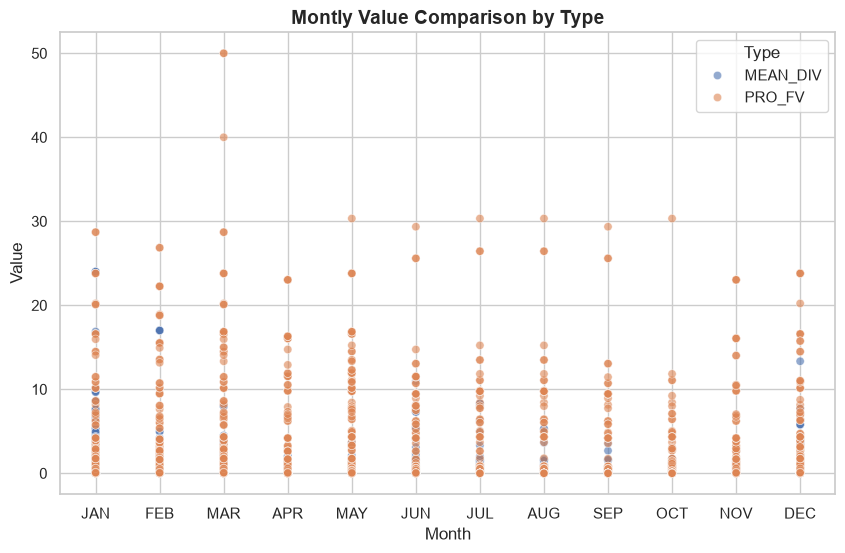

In [28]:
# set up plot area
sns.set_theme(style = "whitegrid")
plt.figure(figsize = (10, 6))

# similar to ggplot + geom_point()
sns.scatterplot(
    data = NV_df_long,
    x = "MONTH",
    y = "MONTHLY_VALUE",
    hue = "TYPE", # set point color based on TYPE (similar to ggplot aes())
    alpha = 0.6 # some transparency in case points overlap
)

plt.title("Montly Value Comparison by Type", fontsize = 14, fontweight = "bold")
plt.xlabel("Month", fontsize = 12)
plt.ylabel("Value", fontsize = 12)
plt.legend(title = "Type")

plt.show()

### Export

In [ ]:
# already created csv from the full dataframe in R, will use that in the Riparian_Pre1914_Water_Use
#
#  NV_df.to_csv("NV_Full_Dataframe_python.csv")

In [ ]:
# To make a shiny dashboard

# 1. Use your existing NV_df_long here!
app_choices = list(NV_df_long['APPLICATION_NUMBER'].unique())

# --- 2. USER INTERFACE (ui) ---
app_ui = ui.page_fluid(
    ui.panel_title("Monthly Usage Dashboard"),
    ui.layout_sidebar(
        ui.sidebar(
            ui.input_select(
                id="App", 
                label="Select Application:", 
                choices=app_choices
            )
        ),
        ui.output_plot("usage_plot")
    )
)

# --- 3. SERVER LOGIC (server) ---
def server(input, output, session):
    
    @reactive.calc
    def filtered_df():
        selected_app = input.App()
        # Using NV_df_long directly
        return NV_df_long[NV_df_long['APPLICATION_NUMBER'] == selected_app]

    @render.plot
    def usage_plot():
        df = filtered_df()
        
        fig, ax = plt.subplots(figsize=(8, 5))
        
        # Note the uppercase column names 'MONTH' and 'TYPE' from your NV_df_long
        sns.scatterplot(
            data=df,
            x='MONTH',
            y='MONTHLY_VALUE',
            hue='TYPE',
            ax=ax,
            s=100
        )
        
        sns.lineplot(
            data=df,
            x='MONTH',
            y='MONTHLY_VALUE',
            hue='TYPE',
            ax=ax,
            legend=False,
            alpha=0.5
        )
        
        ax.set_title(f"Monthly Usage for Application {input.App()}", fontsize=14, fontweight='bold')
        ax.set_xlabel("Month")
        ax.set_ylabel("Usage")
        ax.set_ylim(bottom=0)
        sns.despine()
        
        return fig

app = App(app_ui, server)

# to view, type in terminal: shiny run app.py